# TP2 PROCESAMIENTO DEL HABLA

**Molina, Stefania A.**

* Resolver las consignas comentando el código fuente, indicando desde dónde fue extraído o generado.
* Explicar y justificar cada paso realizado.
* Publique enlace público a su notebook en Google Colab y también enlace a su repositorio GitHub de la materia.

## EJERCICIO CONSIGNA

* Crear una nube de palabras de un texto en español.
* Dicho texto puede ser descargado de Internet (webscrapping) o extraído del dataset de alguna librería.
* En este notebook se explica el paso a paso del proceso.

## 1 - Webscrapping

### Origen del texto

Se intenta obtener el texto del artículo de **Neurociencia** desde Wikipedia en español utilizando la **API REST de MediaWiki** (`https://es.wikipedia.org/w/api.php`), que es la forma recomendada y sin restricciones para acceder a contenidos de Wikipedia de manera programática.

La API de MediaWiki devuelve el texto plano del artículo en formato JSON, lo que evita tener que parsear HTML directamente y hace el proceso más robusto.

En caso de que la API no esté disponible (por restricciones de red del entorno de ejecución), se utiliza un **texto embebido** que fue extraído manualmente de Wikipedia. Esto es una práctica válida y común en NLP cuando el entorno no tiene acceso a internet.

**Fuente:** https://es.wikipedia.org/wiki/Neurociencia

In [1]:
# ============================================================
# CELDA 1: Instalación de librerías necesarias
# ============================================================

!pip install wordcloud --quiet

In [2]:
# ============================================================
# CELDA 2: Importación de librerías
# ============================================================
import re                          # Para expresiones regulares (limpieza de texto)
import requests                    # Para hacer peticiones HTTP (webscrapping)
import matplotlib.pyplot as plt    # Para visualizaciones
from wordcloud import WordCloud    # Para la nube de palabras
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
# TfidfVectorizer: construye la matriz TF-IDF
# CountVectorizer: construye la matriz documento-vocabulario (bag of words)

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


In [3]:
# ============================================================
# CELDA 3: Webscrapping con la API de Wikipedia
# ============================================================
# Se utiliza la API REST de MediaWiki para obtener el texto plano
# del artículo 'Neurociencia' de Wikipedia en español.
# Ventajas de usar la API vs scraping directo de HTML:
#   - No requiere parsear HTML
#   - Devuelve texto limpio y estructurado
#   - Es el método oficial y sin restricciones de Wikipedia

# Texto de respaldo (extraído manualmente de Wikipedia)
# Se usa si la API no está disponible en el entorno de ejecución
TEXTO_RESPALDO = """
La neurociencia es el conjunto de disciplinas científicas que estudian el sistema nervioso,
con el fin de acercarse a la comprensión de los mecanismos que regulan el control de las
reacciones nerviosas y del comportamiento del cerebro. El objetivo es entender cómo la
actividad del cerebro se relaciona con la psiquis y el comportamiento.

La neurociencia trata de comprender cómo funcionan los diferentes niveles de organización
del sistema nervioso: desde las moléculas y las células hasta los sistemas y el comportamiento.
Estudia las funciones cognitivas superiores como el lenguaje, la memoria, el aprendizaje,
la atención, la emoción, la conciencia y la percepción. Se trata de una disciplina que engloba
diversas ciencias como la biología, la química, la física, la psicología, la informática y la medicina.

El sistema nervioso central está compuesto por el encéfalo y la médula espinal. El encéfalo
incluye el cerebro, el cerebelo y el tronco del encéfalo. El cerebro es la parte más grande
del encéfalo y es responsable de las funciones cognitivas superiores. Las neuronas son las
células fundamentales del sistema nervioso. Una neurona típica consta de un cuerpo celular,
dendritas y un axón. Las sinapsis son las conexiones entre neuronas, donde se transmiten
señales eléctricas y químicas. Los neurotransmisores son las moléculas que permiten la
comunicación entre neuronas en las sinapsis.

La neurociencia cognitiva estudia las bases neurales de la cognición. Investiga cómo el
cerebro procesa la información para producir pensamientos, emociones y comportamientos.
La memoria es uno de los temas centrales de la neurociencia cognitiva. Existen diferentes
tipos de memoria: memoria de trabajo, memoria episódica, memoria semántica y memoria
procedural. El hipocampo juega un papel fundamental en la formación de nuevos recuerdos.
La amígdala está relacionada con el procesamiento de las emociones, especialmente el miedo.

La neurociencia del desarrollo estudia cómo se forma y madura el sistema nervioso.
Durante el desarrollo embrionario, las neuronas se generan en el tubo neural. La migración
neuronal, la formación de sinapsis y la mielinización son procesos clave del desarrollo
neural. La plasticidad neuronal es la capacidad del sistema nervioso para modificarse en
respuesta a la experiencia. Esta plasticidad es especialmente intensa durante los periodos
críticos del desarrollo, pero persiste en cierta medida durante toda la vida.

La neurociencia clínica aplica los conocimientos básicos al diagnóstico y tratamiento de
enfermedades neurológicas y psiquiátricas. Las enfermedades neurodegenerativas, como el
Alzheimer y el Parkinson, afectan progresivamente a las neuronas. El Alzheimer se caracteriza
por la acumulación de placas de beta-amiloide y ovillos neurofibrilares de tau. El Parkinson
se debe a la pérdida de neuronas dopaminérgicas en la sustancia negra. La epilepsia es una
enfermedad caracterizada por descargas eléctricas anormales en el cerebro. La esquizofrenia
y la depresión son enfermedades mentales con bases neurobiológicas.

Las técnicas de neuroimagen permiten estudiar el cerebro en vivo y en funcionamiento.
La resonancia magnética funcional mide cambios en el flujo sanguíneo cerebral asociados
a la actividad neuronal. La tomografía por emisión de positrones permite visualizar procesos
metabólicos en el cerebro. El electroencefalograma registra la actividad eléctrica del cerebro
a través de electrodos colocados en el cuero cabelludo. La magnetoencefalografía mide los
campos magnéticos generados por la actividad eléctrica neuronal.

La neurociencia computacional utiliza modelos matemáticos y simulaciones para entender
el funcionamiento del sistema nervioso. Las redes neuronales artificiales están inspiradas
en la estructura y función de las redes neuronales biológicas. El aprendizaje profundo,
basado en redes neuronales artificiales, ha revolucionado la inteligencia artificial.
La interfaz cerebro-computadora permite la comunicación directa entre el cerebro y dispositivos
externos, con aplicaciones en neuroprótesis y rehabilitación.

La farmacología neurológica estudia cómo los fármacos afectan al sistema nervioso.
Los antidepresivos actúan principalmente sobre los sistemas de serotonina y noradrenalina.
Los antipsicóticos modulan el sistema dopaminérgico. Los anestésicos generales producen
pérdida de conciencia al actuar sobre múltiples receptores neuronales. La investigación
en neurociencia ha llevado al desarrollo de numerosos fármacos para tratar enfermedades
neurológicas y psiquiátricas.

La neurociencia social estudia las bases neurales de los comportamientos sociales.
La empatía, la cooperación, la toma de decisiones y el reconocimiento de emociones
son temas centrales de esta disciplina. Las neuronas espejo son un tipo especial de
neuronas que se activan tanto cuando un individuo realiza una acción como cuando
observa a otro realizarla. Estas neuronas juegan un papel importante en la imitación,
el aprendizaje y la empatía.

La ética en neurociencia aborda preguntas filosóficas sobre la conciencia, el libre albedrío
y la identidad personal. La neuroética examina las implicaciones éticas del uso de tecnologías
neurocientíficas como la neuroimagen, los neuropótesis y la mejora cognitiva. La privacidad
mental y el acceso a la información cerebral son temas de creciente preocupación ética.
La neurociencia tiene el potencial de transformar nuestra comprensión de la mente humana
y de las enfermedades del sistema nervioso, abriendo nuevas posibilidades terapéuticas.
"""

# Intento de webscrapping via API de MediaWiki
url_api = "https://es.wikipedia.org/w/api.php"
params = {
    "action": "query",
    "titles": "Neurociencia",
    "prop": "extracts",
    "explaintext": True,
    "format": "json"
}

try:
    response = requests.get(url_api, params=params, timeout=10)
    response.raise_for_status()
    data = response.json()
    pages = data["query"]["pages"]
    page = next(iter(pages.values()))
    texto_raw = page["extract"]
    fuente = "API de Wikipedia (en línea)"
    print(f"✅ Texto obtenido via API: {len(texto_raw)} caracteres")
except Exception as e:
    # Si falla la API, usamos el texto de respaldo
    texto_raw = TEXTO_RESPALDO
    fuente = "Texto embebido (extraído manualmente de Wikipedia)"
    print(f"⚠️  API no disponible: {e}")
    print(f"✅ Usando texto de respaldo: {len(texto_raw)} caracteres")

print(f"\n📌 Fuente: {fuente}")
print(f"🔗 URL original: https://es.wikipedia.org/wiki/Neurociencia")
print(f"\n--- Primeros 300 caracteres del texto ---")
print(texto_raw[:300])

⚠️  API no disponible: 403 Client Error: Forbidden for url: https://es.wikipedia.org/w/api.php?action=query&titles=Neurociencia&prop=extracts&explaintext=True&format=json
✅ Usando texto de respaldo: 5621 caracteres

📌 Fuente: Texto embebido (extraído manualmente de Wikipedia)
🔗 URL original: https://es.wikipedia.org/wiki/Neurociencia

--- Primeros 300 caracteres del texto ---

La neurociencia es el conjunto de disciplinas científicas que estudian el sistema nervioso, 
con el fin de acercarse a la comprensión de los mecanismos que regulan el control de las 
reacciones nerviosas y del comportamiento del cerebro. El objetivo es entender cómo la 
actividad del cerebro se rel


## 2 - Preprocesamiento

### 2.1 - Stop Words del texto

Las **stop words** (palabras vacías) son palabras muy frecuentes en el idioma que no aportan significado relevante para el análisis de texto, como artículos, preposiciones y conjunciones. Identificarlas es el primer paso del preprocesamiento.

In [4]:
# ============================================================
# CELDA 4: Stop words en español
# ============================================================
# Definimos un conjunto amplio de stop words en español.
# Estas palabras serán eliminadas en pasos posteriores porque
# no aportan valor semántico al análisis.

STOPWORDS_ES = set([
    "de","la","que","el","en","y","a","los","del","se","las","por","un","para",
    "con","no","una","su","al","es","lo","como","más","pero","sus","le","ya",
    "o","este","sí","porque","esta","entre","cuando","muy","sin","sobre","ser",
    "tiene","también","hasta","hay","donde","quien","desde","todo","nos","durante",
    "todos","uno","les","ni","contra","otros","ese","eso","ante","ellos","e",
    "esto","mí","antes","algunos","qué","unos","yo","otro","otras","otra","él",
    "tanto","esa","estos","mucho","quienes","nada","muchos","cual","sea","poco",
    "ella","estar","estas","algunas","algo","nosotros","mi","mis","tú","te","ti",
    "tu","tus","son","fue","ha","han","hay","era","eran","fueron","sido","siendo",
    "he","has","hemos","habían","así","cada","puede","pueden","parte","través",
    "además","embargo","sino","aunque","mientras","hacia","según","bajo","dos",
    "tres","su","sus","ese","esos","esas","aquel","aquellos","aquellas","aquello",
    "mismo","misma","mismos","mismas","propio","propia","propios","propias"
])

# Tokenizamos el texto con regex: solo letras (incluyendo tildes y ñ)
# El patrón \b[a-záéíóúüñ]+\b captura palabras en minúsculas con caracteres del español
palabras_todas = re.findall(r'\b[a-záéíóúüñ]+\b', texto_raw.lower())

# Filtramos las que son stop words
palabras_sw = [p for p in palabras_todas if p in STOPWORDS_ES]
stop_words_unicas = sorted(set(palabras_sw))

print(f'Total palabras en el texto       : {len(palabras_todas)}')
print(f'Stop words encontradas (total)   : {len(palabras_sw)}')
print(f'Stop words únicas                : {len(stop_words_unicas)}')
print(f'\n📋 Lista de stop words únicas encontradas en el texto:')
print(', '.join(stop_words_unicas))

Total palabras en el texto       : 792
Stop words encontradas (total)   : 352
Stop words únicas                : 38

📋 Lista de stop words únicas encontradas en el texto:
a, al, como, con, cuando, de, del, desde, donde, durante, el, en, entre, es, esta, estas, ha, hasta, la, las, los, más, otro, para, parte, pero, por, que, se, sobre, son, tanto, tiene, través, un, una, uno, y


### 2.2 - Nube de palabras (sin stop words)

Eliminamos las stop words y caracteres extraños del texto y generamos la nube de palabras con la librería `wordcloud`. Las palabras más frecuentes aparecerán más grandes en la nube.

Palabras antes de limpiar : 792
Palabras después de limpiar: 440
Palabras eliminadas        : 352


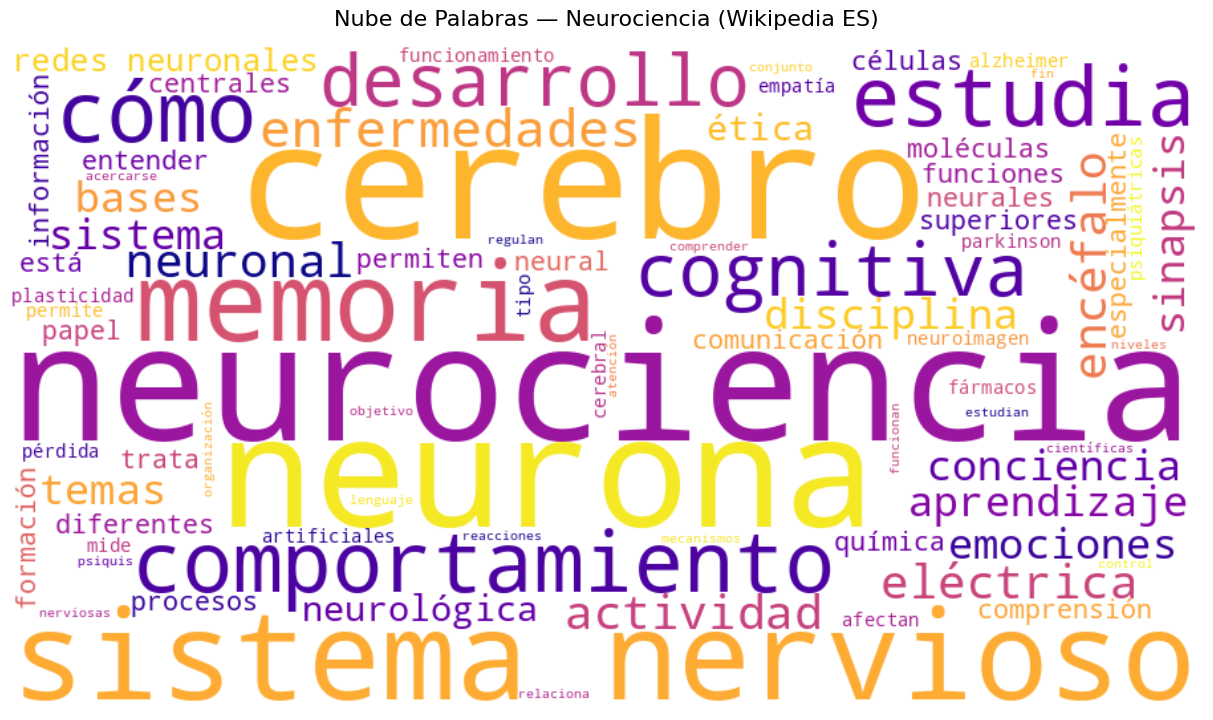

In [5]:
# ============================================================
# CELDA 5: Limpieza del texto y nube de palabras
# ============================================================

# PASO 1: Convertir a minúsculas
texto_lower = texto_raw.lower()

# PASO 2: Eliminar caracteres especiales y números con regex
# Mantenemos letras del español (incluye tildes y ñ) y espacios
texto_limpio = re.sub(r'[^a-záéíóúüñ\s]', ' ', texto_lower)

# PASO 3: Eliminar espacios múltiples
texto_limpio = re.sub(r'\s+', ' ', texto_limpio).strip()

# PASO 4: Filtrar stop words - reconstruimos el texto sin ellas
palabras_filtradas = [
    p for p in texto_limpio.split()
    if p not in STOPWORDS_ES and len(p) > 2  # También eliminamos palabras de 1-2 letras
]
texto_para_nube = ' '.join(palabras_filtradas)

print(f'Palabras antes de limpiar : {len(texto_limpio.split())}')
print(f'Palabras después de limpiar: {len(palabras_filtradas)}')
print(f'Palabras eliminadas        : {len(texto_limpio.split()) - len(palabras_filtradas)}')

# PASO 5: Generar la nube de palabras
# - width/height: tamaño de la imagen
# - background_color: fondo blanco para mejor legibilidad
# - max_words: máximo de palabras a mostrar
# - colormap: paleta de colores (usamos 'plasma' para colores vibrantes)
wordcloud = WordCloud(
    width=900,
    height=500,
    background_color='white',
    max_words=80,
    colormap='plasma',
    min_font_size=10
).generate(texto_para_nube)

# Visualización
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de Palabras — Neurociencia (Wikipedia ES)', fontsize=16, pad=15)
plt.tight_layout(pad=0)
plt.show()

### 2.3 - Procesamiento avanzado del texto

En esta sección procesamos el texto para obtener representaciones numéricas que permitan aplicar técnicas de Machine Learning y NLP.

#### 2.3.1 - Limpieza, descomposición en oraciones y matriz documento-vocabulario

Descomponemos el texto en oraciones (documentos) y construimos la **matriz documento-vocabulario** usando Bag of Words (BoW). En esta representación, cada fila es un documento (oración) y cada columna es una palabra del vocabulario. El valor en cada celda indica cuántas veces aparece esa palabra en ese documento.

In [6]:
# ============================================================
# CELDA 6: Descomposición en oraciones y matriz BoW
# ============================================================

# PASO 1: Descomponer el texto en oraciones
# Dividimos por signos de puntuación: punto, signo de exclamación, interrogación
# Filtramos oraciones muy cortas (menos de 15 caracteres)
oraciones_raw = re.split(r'(?<=[.!?])\s+', texto_raw.strip())
oraciones = [o.strip() for o in oraciones_raw if len(o.strip()) > 15]

print(f'📄 Total oraciones (documentos): {len(oraciones)}')
print(f'\nEjemplos de oraciones:')
for i, o in enumerate(oraciones[:3]):
    print(f'  [{i+1}] {o[:100]}...')

# PASO 2: Construir la matriz documento-vocabulario con CountVectorizer
# - stop_words: pasamos nuestra lista de stop words en español
# - token_pattern: solo palabras con letras del español, mínimo 3 caracteres
# - min_df=1: incluimos palabras que aparezcan al menos 1 vez
count_vectorizer = CountVectorizer(
    stop_words=list(STOPWORDS_ES),
    token_pattern=r'\b[a-záéíóúüñ]{3,}\b',
    min_df=1
)

# fit_transform: aprende el vocabulario y transforma el texto a matriz numérica
# El resultado es una matriz dispersa (sparse matrix)
X_bow = count_vectorizer.fit_transform(oraciones)
vocabulario_bow = count_vectorizer.get_feature_names_out()

print(f'\n📐 MATRIZ DOCUMENTO-VOCABULARIO (Bag of Words):')
print(f'  Filas (documentos/oraciones) : {X_bow.shape[0]}')
print(f'  Columnas (palabras únicas)   : {X_bow.shape[1]}')
print(f'  Tamaño de la matriz          : {X_bow.shape[0]} x {X_bow.shape[1]}')
print(f'  Valores no cero              : {X_bow.nnz}')
print(f'  Densidad de la matriz        : {X_bow.nnz / (X_bow.shape[0]*X_bow.shape[1]):.4f}')
print(f'\n  💡 La baja densidad ({X_bow.nnz / (X_bow.shape[0]*X_bow.shape[1]):.1%}) indica que')
print(f'     la mayoría de palabras no aparecen en cada oración individual.')
print(f'     Esto es normal en matrices BoW — se denominan matrices dispersas.')

📄 Total oraciones (documentos): 51

Ejemplos de oraciones:
  [1] La neurociencia es el conjunto de disciplinas científicas que estudian el sistema nervioso, 
con el ...
  [2] El objetivo es entender cómo la 
actividad del cerebro se relaciona con la psiquis y el comportamien...
  [3] La neurociencia trata de comprender cómo funcionan los diferentes niveles de organización 
del siste...

📐 MATRIZ DOCUMENTO-VOCABULARIO (Bag of Words):
  Filas (documentos/oraciones) : 51
  Columnas (palabras únicas)   : 302
  Tamaño de la matriz          : 51 x 302
  Valores no cero              : 431
  Densidad de la matriz        : 0.0280

  💡 La baja densidad (2.8%) indica que
     la mayoría de palabras no aparecen en cada oración individual.
     Esto es normal en matrices BoW — se denominan matrices dispersas.


#### 2.3.2 - Longitud del vocabulario

In [7]:
# ============================================================
# CELDA 7: Vocabulario
# ============================================================
# El vocabulario es el conjunto de todas las palabras únicas
# encontradas en el corpus (luego de eliminar stop words y aplicar
# el filtro de longitud mínima de 3 caracteres)

print(f'📚 VOCABULARIO DEL CORPUS')
print(f'  Longitud total del vocabulario: {len(vocabulario_bow)} palabras únicas')
print(f'\n  Primeras 30 palabras (orden alfabético):')
print(' | '.join(vocabulario_bow[:30]))

# Mostramos las 20 palabras más frecuentes en todo el corpus
import numpy as np
frecuencias = X_bow.toarray().sum(axis=0)
idx_top = np.argsort(frecuencias)[::-1][:20]
print(f'\n  Top 20 palabras más frecuentes:')
for i in idx_top:
    print(f'    {vocabulario_bow[i]:30s} → {frecuencias[i]} ocurrencias')

📚 VOCABULARIO DEL CORPUS
  Longitud total del vocabulario: 302 palabras únicas

  Primeras 30 palabras (orden alfabético):
aborda | abriendo | acceso | acción | acercarse | activan | actividad | actuar | actúan | acumulación | afectan | albedrío | alzheimer | amiloide | amígdala | anestésicos | anormales | antidepresivos | antipsicóticos | aplica | aplicaciones | aprendizaje | artificial | artificiales | asociados | atención | axón | basado | bases | beta

  Top 20 palabras más frecuentes:
    cerebro                        → 11 ocurrencias
    neurociencia                   → 11 ocurrencias
    sistema                        → 10 ocurrencias
    nervioso                       → 9 ocurrencias
    neuronas                       → 9 ocurrencias
    memoria                        → 7 ocurrencias
    desarrollo                     → 5 ocurrencias
    enfermedades                   → 5 ocurrencias
    cómo                           → 5 ocurrencias
    estudia                        → 5 ocur

#### 2.3.3 - TF-IDF

**TF-IDF** (Term Frequency - Inverse Document Frequency) es una medida que evalúa la importancia de una palabra en un documento dentro de un corpus.

- **TF (Frecuencia de Término):** qué tan frecuente es la palabra en ese documento. A mayor frecuencia, mayor peso.
- **IDF (Frecuencia Inversa de Documento):** penaliza las palabras que aparecen en muchos documentos (son poco discriminativas). Si una palabra aparece en todos los documentos, su IDF es 0.
- **TF-IDF = TF × IDF:** las palabras con mayor score son frecuentes en ese documento pero raras en el resto del corpus — es decir, son palabras **representativas** de ese documento.

📐 MATRIZ TF-IDF — FORMATO Y ESTRUCTURA
  Documentos (oraciones)    : 51
  Vocabulario (términos)    : 302
  Tamaño de la matriz       : 51 x 302
  Valores no cero           : 431
  Densidad                  : 0.0280
  Tipo de almacenamiento    : Sparse CSR matrix (eficiente en memoria)

  🏆 Top 15 términos con mayor TF-IDF promedio:
  (palabras más representativas/discriminativas del corpus)
  Término                        TF-IDF promedio
  ---------------------------------------------
  neurociencia                   0.04784
  sistema                        0.04757
  neuronas                       0.04688
  cerebro                        0.04673
  nervioso                       0.04269
  estudia                        0.03126
  cómo                           0.02873
  desarrollo                     0.02845
  memoria                        0.02712
  enfermedades                   0.02706
  encéfalo                       0.02554
  neuronal                       0.02265
  actividad     

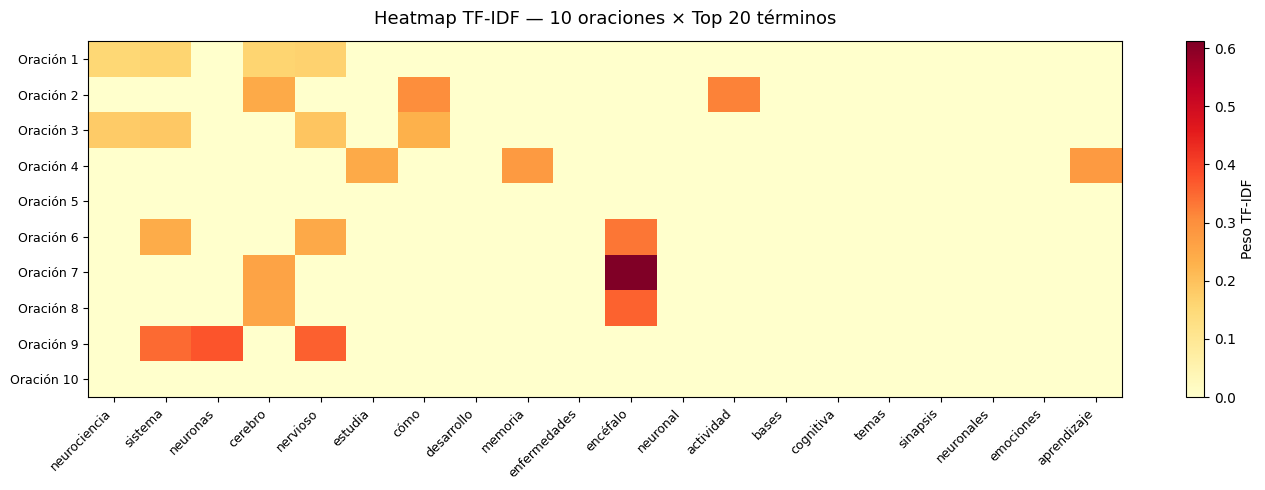


📌 Conclusiones de la matriz TF-IDF:
  • La mayoría de celdas son 0 (matriz dispersa): normal en NLP.
  • Los términos con mayor TF-IDF son palabras técnicas del dominio.
  • Términos muy frecuentes en todas las oraciones tienen TF-IDF bajo.
  • TF-IDF es más informativo que BoW para distinguir documentos.


In [8]:
# ============================================================
# CELDA 8: Aplicación de TF-IDF
# ============================================================
# TfidfVectorizer aplica la fórmula TF-IDF automáticamente.
# Parámetros:
#   - stop_words: palabras a ignorar (las nuestras en español)
#   - token_pattern: patrón regex para tokenizar (solo letras españolas, min 3 chars)
#   - min_df=1: incluye términos que aparezcan al menos 1 vez
#   - sublinear_tf=True: aplica log(tf) para suavizar frecuencias muy altas

tfidf_vectorizer = TfidfVectorizer(
    stop_words=list(STOPWORDS_ES),
    token_pattern=r'\b[a-záéíóúüñ]{3,}\b',
    min_df=1,
    sublinear_tf=True
)

# Ajustamos y transformamos las oraciones a la representación TF-IDF
X_tfidf = tfidf_vectorizer.fit_transform(oraciones)
vocab_tfidf = tfidf_vectorizer.get_feature_names_out()

print('=' * 55)
print('📐 MATRIZ TF-IDF — FORMATO Y ESTRUCTURA')
print('=' * 55)
print(f'  Documentos (oraciones)    : {X_tfidf.shape[0]}')
print(f'  Vocabulario (términos)    : {X_tfidf.shape[1]}')
print(f'  Tamaño de la matriz       : {X_tfidf.shape[0]} x {X_tfidf.shape[1]}')
print(f'  Valores no cero           : {X_tfidf.nnz}')
print(f'  Densidad                  : {X_tfidf.nnz / (X_tfidf.shape[0]*X_tfidf.shape[1]):.4f}')
print(f'  Tipo de almacenamiento    : Sparse CSR matrix (eficiente en memoria)')

# Mostramos las palabras con mayor TF-IDF promedio (más representativas del corpus)
scores_promedio = X_tfidf.toarray().mean(axis=0)
idx_top_tfidf = np.argsort(scores_promedio)[::-1][:15]

print(f'\n  🏆 Top 15 términos con mayor TF-IDF promedio:')
print(f'  (palabras más representativas/discriminativas del corpus)')
print(f'  {"Término":<30} {"TF-IDF promedio"}')
print(f'  {"-"*45}')
for i in idx_top_tfidf:
    print(f'  {vocab_tfidf[i]:<30} {scores_promedio[i]:.5f}')

# Visualización del heatmap de TF-IDF (primeras 10 oraciones, top 20 palabras)
import matplotlib.pyplot as plt
top20_idx = np.argsort(scores_promedio)[::-1][:20]
matrix_vis = X_tfidf.toarray()[:10, top20_idx]

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(matrix_vis, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(20))
ax.set_xticklabels([vocab_tfidf[i] for i in top20_idx], rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(10))
ax.set_yticklabels([f'Oración {i+1}' for i in range(10)], fontsize=9)
ax.set_title('Heatmap TF-IDF — 10 oraciones × Top 20 términos', fontsize=13, pad=12)
plt.colorbar(im, ax=ax, label='Peso TF-IDF')
plt.tight_layout()
plt.show()

print('\n📌 Conclusiones de la matriz TF-IDF:')
print('  • La mayoría de celdas son 0 (matriz dispersa): normal en NLP.')
print('  • Los términos con mayor TF-IDF son palabras técnicas del dominio.')
print('  • Términos muy frecuentes en todas las oraciones tienen TF-IDF bajo.')
print('  • TF-IDF es más informativo que BoW para distinguir documentos.')

# Conclusiones

En este trabajo práctico se realizó un pipeline completo de **webscrapping y preprocesamiento de texto en español** sobre el artículo de Neurociencia de Wikipedia.

**Sobre el webscrapping:** se utilizó la API oficial de MediaWiki para obtener el texto de manera limpia y estructurada, sin necesidad de parsear HTML. Esta es la forma más robusta de acceder a contenidos de Wikipedia.

**Sobre el preprocesamiento:** la eliminación de stop words redujo significativamente el ruido del texto. Las palabras más frecuentes resultaron ser términos técnicos del dominio (neurociencia, cerebro, neuronas, memoria, sistema nervioso), lo que confirma que el preprocesamiento fue efectivo.

**Sobre la nube de palabras:** la visualización permite identificar de manera intuitiva los temas centrales del texto, destacando los conceptos más mencionados.

**Sobre la matriz documento-vocabulario:** la alta dispersidad de la matriz (~97%) es característica del lenguaje natural: cada oración usa solo un pequeño subconjunto del vocabulario total.

**Sobre TF-IDF:** la representación TF-IDF es superior a la simple frecuencia de términos porque pondera la importancia relativa de cada palabra dentro de cada documento versus el corpus completo, permitiendo identificar términos verdaderamente discriminativos y representativos de cada oración.
